# STL-Rocket: Local and Global Explanations of Time-Series Classifiers


## Setup

In [1]:
import copy
from collections import defaultdict
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from aeon.datasets import load_classification
from stlkernel.distribution_formulae import F0
from torcheck.stl import Atom, Not, And, Or, Globally, Eventually, Until
from torcheck import simplify
from glmnet import LogitNet
from sklearn.metrics import balanced_accuracy_score
from glmnet.scorer import make_scorer

torch.manual_seed(42)
np.random.seed(42)

## Dataset

In [43]:
DATASET_NAME = "Libras"
TS_tr, y_tr = load_classification(DATASET_NAME, split="TRAIN")
TS_te, y_te = load_classification(DATASET_NAME, split="TEST")
classes = np.unique(y_tr)
N, V, T = TS_tr.shape

/tmp/ipykernel_54458/1962846678.py:2: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  TS_tr, y_tr = load_classification(DATASET_NAME, split="TRAIN")
/tmp/ipykernel_54458/1962846678.py:3: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  TS_te, y_te = load_classification(DATASET_NAME, split="TEST")


In [44]:
print(f"train: {TS_tr.shape}")
print(f"test: {TS_te.shape}")
print(f"n_classes: {len(classes)}")
print(f"classes: {classes}")

train: (180, 2, 45)
test: (180, 2, 45)
n_classes: 15
classes: ['1' '10' '11' '12' '13' '14' '15' '2' '3' '4' '5' '6' '7' '8' '9']


## Feature Extraction



In [45]:
class StateVariableStandardScaler:
    def __init__(self, eps=1e-8):
        self.mean = None
        self.std = None
        self.eps = eps

    def fit(self, X):
        self.mean = np.mean(X, axis=(0, 2), keepdims=True)
        self.std = np.std(X, axis=(0, 2), keepdims=True) 
        return self

    def transform(self, X):
        return (X - self.mean) / (self.std + self.eps)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def robustness(TS, formulae):
    with torch.no_grad():
        rhos = [
            phi.quantitative(torch.from_numpy(TS), evaluate_at_all_times=False, normalize=False).cpu().numpy()
            for phi in formulae
        ]
        rhos = np.stack(rhos, axis=1)
    return rhos.ravel() if len(formulae)==1 else rhos


def shift_atom_thresholds(node, delta, sign=1):
    if isinstance(node, Atom):
        effective_delta = delta * sign
        if node.lte:
            node.threshold += effective_delta   # rho = threshold - x
        else:
            node.threshold -= effective_delta   # rho = x - threshold
    elif isinstance(node, Not):
        shift_atom_thresholds(node.child, delta, sign=-sign)
    elif isinstance(node, (And, Or)):
        shift_atom_thresholds(node.left_child, delta, sign)
        shift_atom_thresholds(node.right_child, delta, sign)
    elif isinstance(node, (Globally, Eventually)):
        shift_atom_thresholds(node.child, delta, sign)
    elif isinstance(node, Until):
        shift_atom_thresholds(node.left_child, delta, sign)
        shift_atom_thresholds(node.right_child, delta, sign)
    else:
        raise TypeError(f"unknown node type: {type(node).__name__}")


def plot_robustness_kde(phi, X, y, classes, target_class, title=None):
    rho = robustness(X, [phi])
    grid = np.linspace(rho.min() - 1, rho.max() + 1, 400)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for c in classes:
        rho_c = rho[y == c]
        is_target = (c == target_class)
        #color = "red" if is_target else "gray"
        if rho_c.size < 2 or np.allclose(rho_c.std(), 0):
            ax.axvline(rho_c.mean(), linestyle="--", #color=color,
                       label=f"{c} (n={rho_c.size}, degenerate)")
            continue
        kde = gaussian_kde(rho_c, 0.1)
        ax.plot(grid, kde(grid), #color=color,
                label=f"{c} (n={rho_c.size})")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":", label="rho = 0")
    ax.set_xlabel("rho"); ax.set_ylabel("density")
    if title is not None:
        ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
N_FORMULAE = 1000
DEPTH_MAX_FORMULAE = 3
SEED_F0 = 0
LOCAL_EXPL_TOP_M = 5
LOCAL_EXPL_PRECISION_THRESHOLD = 0.9

svss = StateVariableStandardScaler()
TS_tr = svss.fit_transform(TS_tr)
TS_te = svss.transform(TS_te)

formulae_generator = F0(
    n_vars = V,
    v_min = np.percentile(TS_tr, 2,  axis=(0, 2)),
    v_max = np.percentile(TS_tr, 98, axis=(0, 2)),
    t_max = T - 1,
    depth_max = DEPTH_MAX_FORMULAE,
    seed = SEED_F0,
    only_temporal = True,
    until_weight = 0.0
)

formulae = formulae_generator.sample(N_FORMULAE)

X_tr = robustness(TS_tr, formulae)
X_te = robustness(TS_te, formulae)

means = X_tr.mean(axis=0)
std = X_tr.std(axis=0)

for j in range(len(formulae)):
    shift_atom_thresholds(formulae[j], delta=-means[j])

X_tr -= means 
X_te -= means
X_tr /= std
X_te /= std

## Classifier


In [68]:
balanced_accuracy_scorer = make_scorer(balanced_accuracy_score)

model = LogitNet(
    alpha = 1.0,
    n_splits = 3,
    cut_point = 1,
    fit_intercept = False,
    standardize = True,
    n_jobs = 8,
    max_iter = 1_000_000,
    verbose = True,
    scoring = balanced_accuracy_scorer
)

model.fit(X_tr, y_tr)
y_pred_tr = model.predict(X_tr)
y_pred_te = model.predict(X_te)
W = model.coef_                  
b = model.intercept_                    

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   3 out of   3 | elapsed:   12.7s finished


In [59]:
print(f"Balanced accuracy train set: {balanced_accuracy_score(y_tr, y_pred_tr):.3f}")
print(f"Balanced accuracy test set: {balanced_accuracy_score(y_te, y_pred_te):.3f}")
print(f"Non-zero columns of W: {(W != 0).any(axis=0).sum()} / {W.shape[1]}")

Balanced accuracy train set: 0.972
Balanced accuracy test set: 0.839
Non-zero columns of W: 302 / 1000


## Local Explanations

In [60]:
def per_competitor_contributions(W, x, k):
    # W must already have one row per class (binary is stacked in build_local_explanation)
    if W.shape[0] == 1:
        return np.stack([2*W[k], -2*W[k]])

    return np.stack([(W[k] - W[l]) * x for l in range(W.shape[0]) if l != k])


def get_top_m_features(C, m):
    aggregated = C.sum(axis=0)
    return np.argsort(-aggregated)[:m].tolist()


def _reparametrize(phi_original, rho, rho_target, k, y_tr):
    """rho = robustness of phi_original on the training set (precomputed)."""
    y = np.asarray(y_tr)
    phi = copy.deepcopy(phi_original)

    other_classes = np.unique(y[y != k])
    med_others = {c: np.median(rho[y == c]) for c in other_classes}
    below = {c: v for c, v in med_others.items() if v < rho_target}
    above = {c: v for c, v in med_others.items() if v > rho_target}

    if not below and not above:
        ref_class = other_classes[0]
    elif not below:
        ref_class = min(above, key=above.get)
    elif not above:
        ref_class = max(below, key=below.get)
    elif len(below) == len(above):
        ref_class = max(med_others, key=lambda c: abs(med_others[c] - rho_target))
    elif len(below) > len(above):
        ref_class = max(below, key=below.get)
    else:
        ref_class = min(above, key=above.get)

    med_ref = med_others[ref_class]
    if rho_target < med_ref:
        phi = Not(phi)
        rho, rho_target, med_ref = -rho, -rho_target, -med_ref

    delta_star = -(rho_target + med_ref) / 2
    shift_atom_thresholds(phi, delta_star)
    return phi, rho + delta_star


def reparametrize_formula_global(phi_original, k, TS_tr, y_tr):
    # target robustness = class MEDIAN over training data
    rho = robustness(TS_tr, [phi_original])
    rho_target = float(np.median(rho[np.asarray(y_tr) == k]))
    phi, _ = _reparametrize(phi_original, rho, rho_target, k, y_tr)
    return phi


def reparametrize_formula_local(phi_original, ts, k, TS_tr, y_tr):
    # target robustness = robustness of THIS time series
    rho = robustness(TS_tr, [phi_original])
    rho_target = float(robustness(ts[None, ...], [phi_original])[0])
    phi, _ = _reparametrize(phi_original, rho, rho_target, k, y_tr)
    return phi


def greedy_precise_picks(x, X_tr, std, W, model, formulae, y_tr, k, m, precision_threshold):
    y_tr = np.asarray(y_tr)
    target_class = model.classes_[k]

    C = per_competitor_contributions(W, x, k)
    top_m_features = get_top_m_features(C, m)

    usable = {}
    for j in top_m_features:
        rho_j = X_tr[:, j] * std[j]
        rho_target = float(x[j] * std[j])
        phi_j, rho_j_new = _reparametrize(formulae[j], rho_j, rho_target, target_class, y_tr)
        usable[j] = (phi_j, rho_j_new)

    remaining = list(usable)
    picks, reparametrized = [], {}
    rho_current = np.full(len(y_tr), np.inf)

    while remaining:
        best_j, best_precision, best_rho, best_phi = None, -np.inf, None, None
        for j in remaining:
            phi_j, rho_j = usable[j]
            pos_mask = np.minimum(rho_current, rho_j) > 0
            tot = pos_mask.sum()
            precision = float((y_tr[pos_mask] == target_class).sum() / tot) if tot else 0.0
            if precision > best_precision:
                best_precision, best_j, best_rho, best_phi = precision, j, rho_j, phi_j

        if best_j is None:
            break
        picks.append(best_j)
        remaining.remove(best_j)
        reparametrized[best_j] = simplify(best_phi)
        rho_current = np.minimum(rho_current, best_rho)
        if best_precision >= precision_threshold:
            break

    return picks, reparametrized


def conjunction(phis):
    if not phis:
        raise ValueError("empty conjunction")
    out = phis[0]
    for phi in phis[1:]:
        out = And(out, phi)
    return out


def build_local_explanation(x, model, formulae, X_tr, std, y_tr, m, precision_threshold):
    W, b = model.coef_, model.intercept_
    if W.shape[0] == 1:
        W = np.vstack([-W, W])
        b = np.concatenate([-b, b])

    k = int(np.argmax(W @ x + b))
    y_pred = model.classes_[k]

    picks, reparametrized = greedy_precise_picks(
        x, X_tr, std, W, model, formulae, y_tr, k, m, precision_threshold
    )
    if not picks:
        return None, y_pred, []

    local_explanation = simplify(conjunction([reparametrized[j] for j in picks]))
    return local_explanation, y_pred, picks


def evaluate_local_explanation(phi_local, target_class, TS_tr, y_tr):
    y_tr = np.asarray(y_tr)
    pos_mask = robustness(TS_tr, [phi_local]) > 0
    tot_positive = int(pos_mask.sum())
    if tot_positive == 0:
        return 0.0, 0, 0
    true_positive = int((y_tr[pos_mask] == target_class).sum())
    false_positive = tot_positive - true_positive
    precision = true_positive / tot_positive
    return precision, true_positive, false_positive

In [61]:
locals_per_class = defaultdict(list)

for i in range(X_tr.shape[0]):
    x = X_tr[i]

    phi_local, pred_class, picks = build_local_explanation(
        x, model, formulae, X_tr, std, y_tr,
        m=LOCAL_EXPL_TOP_M, precision_threshold=LOCAL_EXPL_PRECISION_THRESHOLD,
    )

    if phi_local is not None:
        precision, n_tp, n_fp = evaluate_local_explanation(phi_local, pred_class, TS_tr, y_tr)
    else:
        precision, n_tp, n_fp = 0.0, 0, 0

    print(f"sample {i:>4} | pred_class={pred_class!s:>10} | true_class={y_tr[i]!s:>10} | "
          f"precision={precision:.3f} | n_tp={n_tp:>3} | n_fp={n_fp:>3} | "
          f"picks={picks} | formula={phi_local}")

    locals_per_class[pred_class].append([i, phi_local, picks, precision, n_tp, n_fp])

print("\n" + "=" * 60)
print("PER-CLASS SUMMARY")
print("=" * 60)
for cls in sorted(locals_per_class):
    entries = locals_per_class[cls]
    n = len(entries)
    found = [e for e in entries if e[1] is not None]

    print(f"\nclass={cls}  (n={n}, with explanation={len(found)})")
    if not found:
        continue
    precisions = [p for (_, _, _, p, _, _) in found]
    tps = [tp for (_, _, _, _, tp, _) in found]
    fps = [fp for (_, _, _, _, _, fp) in found]
    lengths = [len(picks) for (_, _, picks, _, _, _) in found]
    print(f"  mean precision : {np.mean(precisions):.3f}  (std={np.std(precisions):.3f})")
    print(f"  mean n_tp      : {np.mean(tps):.1f}  (std={np.std(tps):.1f})")
    print(f"  mean n_fp      : {np.mean(fps):.1f}  (std={np.std(fps):.1f})")
    print(f"  mean length    : {np.mean(lengths):.2f}")

sample    0 | pred_class=         1 | true_class=         1 | precision=1.000 | n_tp=  1 | n_fp=  0 | picks=[59, 87] | formula=( ( F[13,17](x_1 => 1.3395) ) ∧ ( F[15,22](x_0 <= -1.8004) ) )
sample    1 | pred_class=         1 | true_class=         1 | precision=1.000 | n_tp=  2 | n_fp=  0 | picks=[59, 302] | formula=( ( F[13,17](x_1 => 1.3674) ) ∧ ( F[15,25](x_0 => 1.3394) ) )
sample    2 | pred_class=         1 | true_class=         1 | precision=1.000 | n_tp=  1 | n_fp=  0 | picks=[792] | formula=( F[12,16](x_1 => 2.1017) )
sample    3 | pred_class=         1 | true_class=         1 | precision=1.000 | n_tp=  1 | n_fp=  0 | picks=[792, 87] | formula=( ( F[12,16](x_1 => 1.5379) ) ∧ ( F[15,22](x_0 <= -1.4895) ) )
sample    4 | pred_class=         1 | true_class=         1 | precision=1.000 | n_tp=  3 | n_fp=  0 | picks=[302, 87] | formula=( ( F[15,25](x_0 => 1.4051) ) ∧ ( F[15,22](x_0 <= -1.0749) ) )
sample    5 | pred_class=         1 | true_class=         1 | precision=1.000 | n_tp= 

# Global Explanations

In [62]:
def disjunction(phis):
    if not phis:
        raise ValueError("empty disjunction")
    out = phis[0]
    for phi in phis[1:]:
        out = Or(out, phi)
    return out


def simplify_global(phi_disjuncts, TS_tr):
    """phi_disjuncts: the list of local formulas that were OR'd together.
    Returns a minimal sublist whose union mask is identical -> same coverage & FP."""
    masks = [robustness(TS_tr, [phi]) > 0 for phi in phi_disjuncts]

    full = np.zeros(len(TS_tr), dtype=bool)
    for mk in masks:
        full |= mk

    # greedy: keep disjuncts that add new points, until union == full
    order = sorted(range(len(masks)), key=lambda k: -masks[k].sum())  # biggest first
    kept, covered = [], np.zeros(len(TS_tr), dtype=bool)
    for k in order:
        if (masks[k] & ~covered).any():        # adds something new
            kept.append(phi_disjuncts[k])
            covered |= masks[k]
        if covered.sum() == full.sum():        # reconstructed the full set
            break
    return kept


def dedup_disjuncts(phi_disjuncts, masks, agreement):
    """3. Merge near-identical disjuncts: if two positive masks agree on
    >= `agreement` fraction of samples, keep only the first (larger) one."""
    order = sorted(range(len(masks)), key=lambda i: -masks[i].sum())
    kept = []
    for i in order:
        if all((masks[i] == masks[j]).mean() < agreement for j in kept):
            kept.append(i)
    return kept


def prune_disjuncts(idx, masks, target, min_gain):
    """1. Greedily drop disjuncts whose removal costs less than `min_gain`
    in score (coverage - FP rate)."""
    def score_of(indices):
        u = np.logical_or.reduce([masks[i] for i in indices])
        cov = (u & target).sum() / target.sum()
        fp = (u & ~target).sum() / (~target).sum()
        return cov - fp

    idx = list(idx)
    improved = True
    while improved and len(idx) > 1:
        improved = False
        base = score_of(idx)
        for i in list(idx):
            rest = [j for j in idx if j != i]
            if score_of(rest) >= base - min_gain:
                idx.remove(i)
                improved = True
                break
    return idx


def simplify_global(phi_disjuncts, TS_tr, y_tr, target_class,
                    agreement, min_gain):
    """Dedup near-identical disjuncts, then prune low-value ones."""
    y = np.asarray(y_tr)
    target = y == target_class
    masks = [robustness(TS_tr, [phi]) > 0 for phi in phi_disjuncts]

    idx = dedup_disjuncts(phi_disjuncts, masks, agreement)
    idx = prune_disjuncts(idx, masks, target, min_gain)
    return [phi_disjuncts[i] for i in idx]


def build_global_explanations(locals_per_class, TS_tr, y_tr, agreement, min_gain):
    global_per_class = {}
    for cls, lst in locals_per_class.items():
        phis = [phi for _, phi, _, _, _, _ in lst if phi is not None]
        if phis:
            kept = simplify_global(phis, TS_tr, y_tr, cls, agreement, min_gain)
            global_per_class[cls] = reparametrize_formula_global(
                disjunction(kept), cls, TS_tr, y_tr
            )
    return global_per_class



In [63]:
global_per_class = build_global_explanations(locals_per_class, TS_tr, y_tr, 1.00, 0.5)

## Evaluation Global Explanations



In [64]:
def evaluate_global(global_per_class, TS_eval, y_eval):
    y_eval = np.asarray(y_eval)
    print(f"{'class':<12s} {'coverage':>10s} {'FP rate':>10s}")
    print("-" * 44)
    for cls, phi_global in global_per_class.items():
        rho = robustness(TS_eval, [phi_global])
        target_mask = (y_eval == cls)
        coverage = (rho[target_mask] > 0).mean() if target_mask.any() else float("nan")
        fp_rate = (rho[~target_mask] > 0).mean() if (~target_mask).any() else float("nan")
        print(f"{cls!s:<12s} {coverage:>9.1%} {fp_rate:>9.1%} {phi_global}")


print("Evaluation on train set:")
evaluate_global(global_per_class, TS_tr, y_tr)

print("\nEvaluation on test set:")
evaluate_global(global_per_class, TS_te, y_te)

Evaluation on train set:
class          coverage    FP rate
--------------------------------------------
1                58.3%      8.3% ( ( F[15,22](x_0 <= -0.8673) ) ∧ ( F[28,29](x_1 <= -0.459) ) )
2                75.0%      7.1% ( ( G[9,inf](x_1 => -0.5137) ) ∧ ( F[4,17](x_0 <= -0.7284) ) )
3                66.7%      9.5% ( ( G[9,inf](x_0 <= 0.8518) ) ∧ ( F[4,15](x_1 <= -0.3253) ) )
8                50.0%     13.1% ( ( G[10,inf](x_0 => -1.1358) ) ∧ ( G[32,inf](x_1 <= -0.2474) ) )
4                91.7%      8.9% ( ( ( ( ( G[27,29](x_0 <= 0.1318) ) ∧ ( G[39,inf](x_1 => -0.2916) ) ) ∧ ( G[19,31](x_0 <= 0.8372) ) ) ∧ ( G[2,inf](x_0 <= 1.1481) ) ) ∧ ( F(x_1 => 0.3836) ) )
5                50.0%     13.7% ( ( ( G[2,8](x_1 <= 0.4181) ) ∧ ( G[26,41](x_1 => -0.7183) ) ) ∧ ( G(x_0 <= 1.2516) ) )
6                58.3%      5.4% ( ( F[27,33](x_1 => 0.9344) ) ∧ ( F[16,31](x_0 <= -1.2589) ) )
7                50.0%     10.7% ( ( G[14,33](x_1 => -0.0625) ) ∧ ( F[7,inf](x_0 <= -1.2905) ) )
15 

In [65]:
def positive_mask(phi, TS):
    return robustness(TS, [phi]) > 0


def _children_replacements(node):
    """Candidate smaller versions of this node."""
    if isinstance(node, (And, Or)):
        return [node.left_child, node.right_child]
    if isinstance(node, Not):
        if isinstance(node.child, Not):
            return [node.child.child]      # ¬¬phi -> phi
    return []


def _iter_nodes(node):
    """Yield (parent, attr_name, child) for every edge in the tree."""
    for attr in ("child", "left_child", "right_child"):
        child = getattr(node, attr, None)
        if child is not None and not isinstance(child, Atom):
            yield node, attr, child
            yield from _iter_nodes(child)
        elif isinstance(child, Atom):
            yield node, attr, child


def simplify_data_aware(phi, TS, agreement):
    """Greedily shrink phi while its positive mask on TS stays
    >= `agreement` identical to the original. agreement=1.0 -> exact."""
    phi = copy.deepcopy(phi)
    ref_mask = positive_mask(phi, TS)

    def ok(candidate):
        return (positive_mask(candidate, TS) == ref_mask).mean() >= agreement

    improved = True
    while improved:
        improved = False

        # root-level replacement
        for rep in _children_replacements(phi):
            if ok(rep):
                phi = rep
                improved = True
                break
        if improved:
            continue

        # internal-node replacement
        for parent, attr, child in _iter_nodes(phi):
            for rep in _children_replacements(child):
                old = getattr(parent, attr)
                setattr(parent, attr, rep)
                if ok(phi):
                    improved = True
                    break
                setattr(parent, attr, old)      # revert
            if improved:
                break

    return phi


def round_thresholds(phi, TS, decimals, agreement):
    """Round atom thresholds where it doesn't change behavior on TS."""
    phi = copy.deepcopy(phi)
    ref_mask = positive_mask(phi, TS)

    def visit(node):
        if isinstance(node, Atom):
            old = node.threshold
            node.threshold = round(float(old), decimals)
            if (positive_mask(phi, TS) == ref_mask).mean() < agreement:
                node.threshold = old        # revert
            return
        for attr in ("child", "left_child", "right_child"):
            child = getattr(node, attr, None)
            if child is not None:
                visit(child)

    visit(phi)
    return phi

In [66]:
for cls in global_per_class:
    phi = global_per_class[cls]
    phi = simplify_data_aware(phi, TS_tr, agreement=0.98)
    phi = round_thresholds(phi, TS_tr, decimals=1, agreement=0.98)
    global_per_class[cls] = phi

print("Evaluation on train set:")
evaluate_global(global_per_class, TS_tr, y_tr)

print("\nEvaluation on test set:")
evaluate_global(global_per_class, TS_te, y_te)

Evaluation on train set:
class          coverage    FP rate
--------------------------------------------
1                58.3%      7.1% ( ( F[15,22](x_0 <= -0.9) ) ∧ ( F[28,29](x_1 <= -0.5) ) )
2                66.7%      6.5% ( ( G[9,inf](x_1 => -0.5) ) ∧ ( F[4,17](x_0 <= -0.7284) ) )
3                66.7%     10.7% ( ( G[9,inf](x_0 <= 0.9) ) ∧ ( F[4,15](x_1 <= -0.3) ) )
8                50.0%     11.3% ( ( G[10,inf](x_0 => -1.1) ) ∧ ( G[32,inf](x_1 <= -0.2474) ) )
4                83.3%      9.5% ( ( ( G[27,29](x_0 <= 0.1) ) ∧ ( G[39,inf](x_1 => -0.3) ) ) ∧ ( G[2,inf](x_0 <= 1.1) ) )
5                58.3%     14.9% ( ( ( G[2,8](x_1 <= 0.4) ) ∧ ( G[26,41](x_1 => -0.7) ) ) ∧ ( G(x_0 <= 1.3) ) )
6                58.3%      4.8% ( ( F[27,33](x_1 => 0.9) ) ∧ ( F[16,31](x_0 <= -1.3) ) )
7                50.0%     11.9% ( ( G[14,33](x_1 => -0.1) ) ∧ ( F[7,inf](x_0 <= -1.3) ) )
15               50.0%     46.4% ( ¬( ( G[0,17](x_0 <= 1.1446) ) ∧ ( G[28,30](x_1 <= 0.8) ) ) )
9              

Evaluation on train set:
( ( F[15,22](x_0 <= -0.9) ) ∧ ( F[28,29](x_1 <= -0.5) ) )


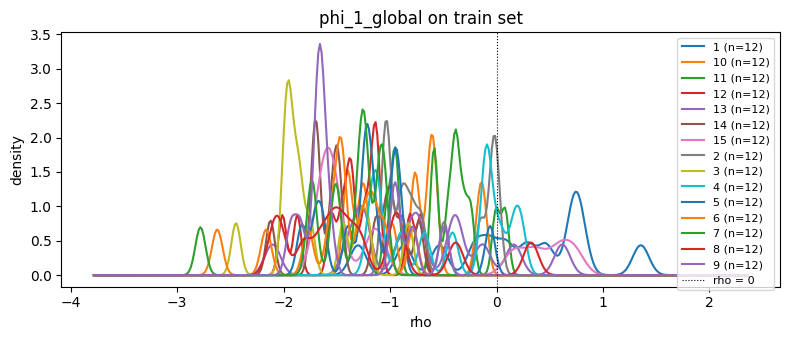

( ( G[9,inf](x_1 => -0.5) ) ∧ ( F[4,17](x_0 <= -0.7284) ) )


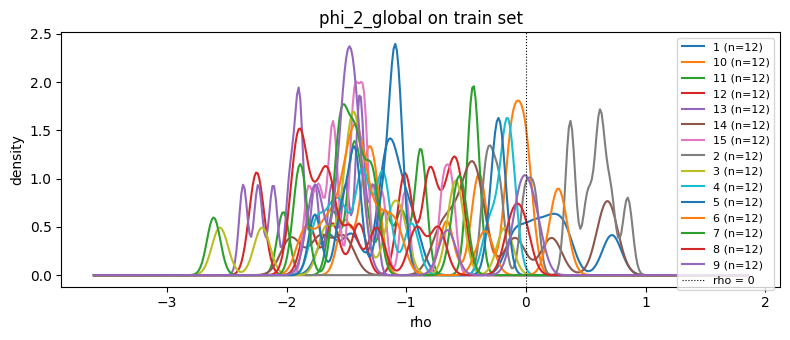

( ( G[9,inf](x_0 <= 0.9) ) ∧ ( F[4,15](x_1 <= -0.3) ) )


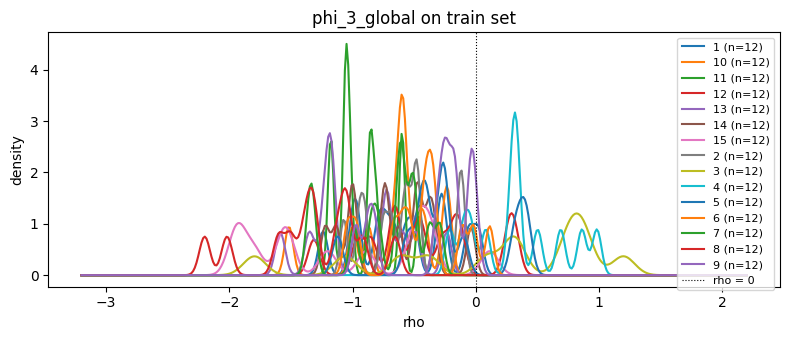

( ( G[10,inf](x_0 => -1.1) ) ∧ ( G[32,inf](x_1 <= -0.2474) ) )


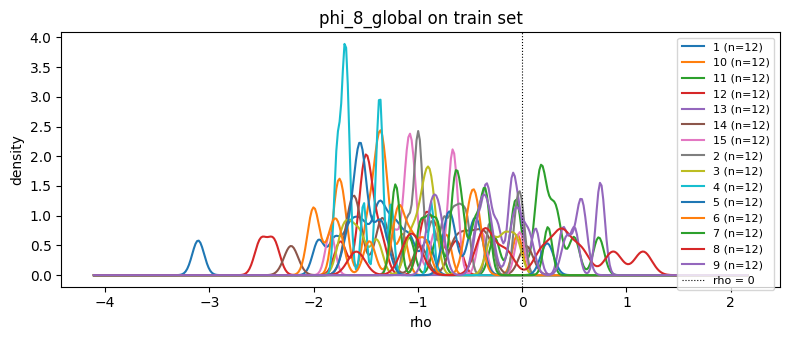

( ( ( G[27,29](x_0 <= 0.1) ) ∧ ( G[39,inf](x_1 => -0.3) ) ) ∧ ( G[2,inf](x_0 <= 1.1) ) )


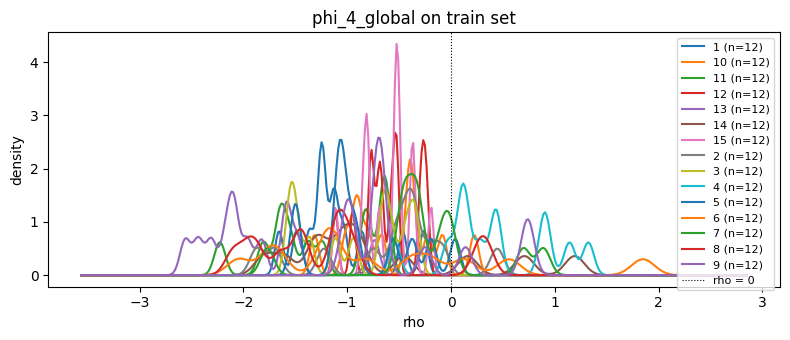

( ( ( G[2,8](x_1 <= 0.4) ) ∧ ( G[26,41](x_1 => -0.7) ) ) ∧ ( G(x_0 <= 1.3) ) )


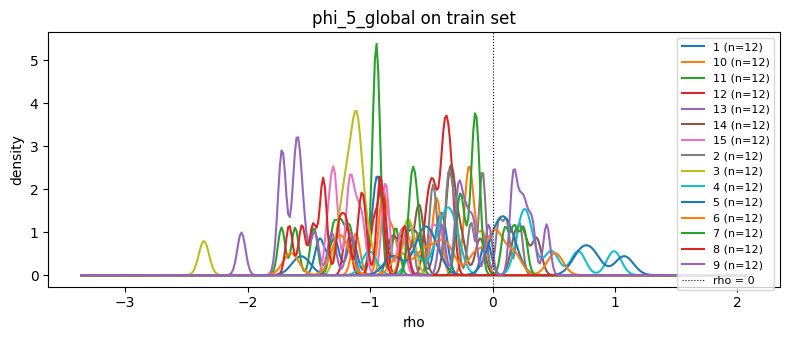

( ( F[27,33](x_1 => 0.9) ) ∧ ( F[16,31](x_0 <= -1.3) ) )


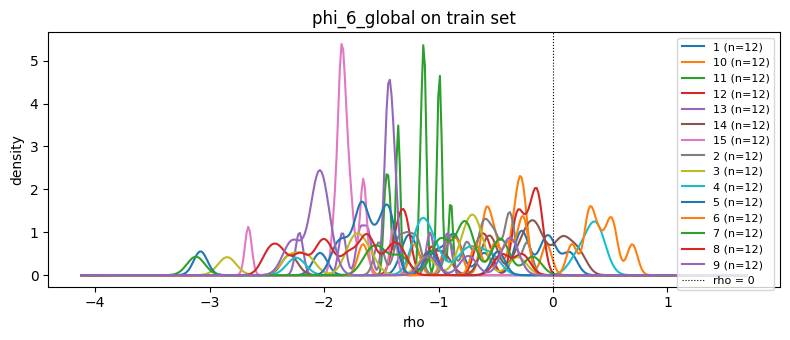

( ( G[14,33](x_1 => -0.1) ) ∧ ( F[7,inf](x_0 <= -1.3) ) )


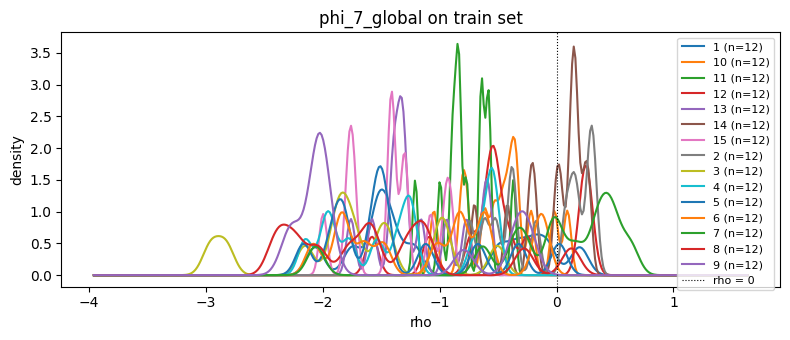

( ¬( ( G[0,17](x_0 <= 1.1446) ) ∧ ( G[28,30](x_1 <= 0.8) ) ) )


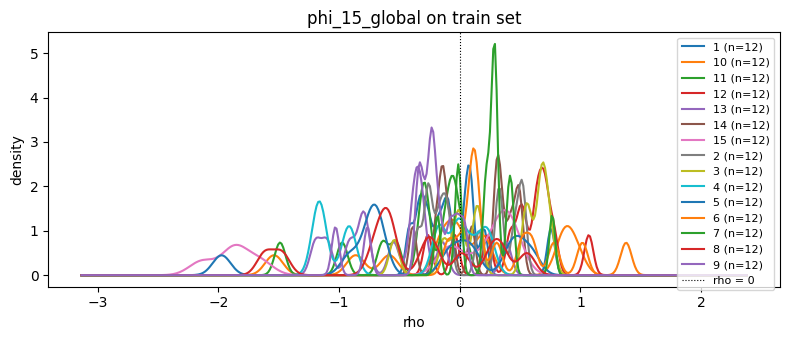

( ( G(x_1 <= 1.1) ) ∧ ( G[5,inf](x_0 <= 1.1) ) )


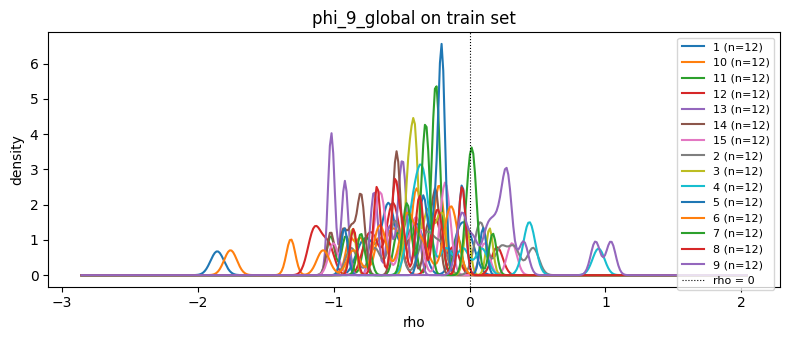

( ( F[0,10](x_0 => 0.6) ) ∧ ( F[22,27](x_1 => 0.5642) ) )


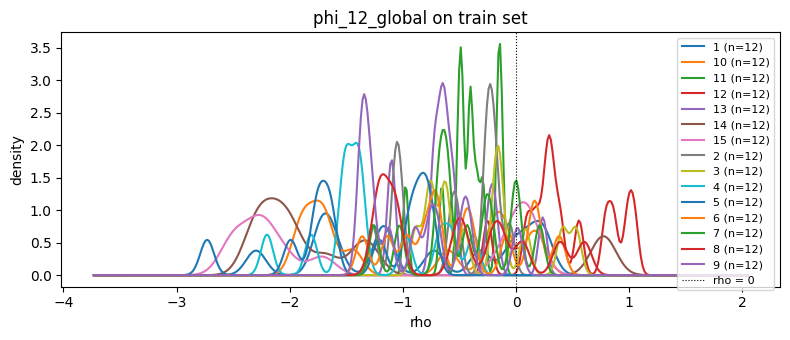

( ( ( F[21,32](x_1 => -0.1) ) ∧ ( G[19,31](x_0 <= 0.5644) ) ) ∧ ( F[1,12](x_1 => -0.1) ) )


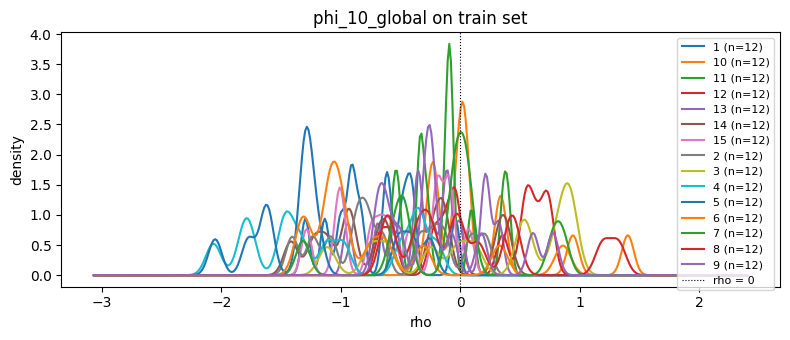

( ( G[1,4](x_1 => 0.4) ) ∧ ( F[13,19](x_0 <= -0.4) ) )


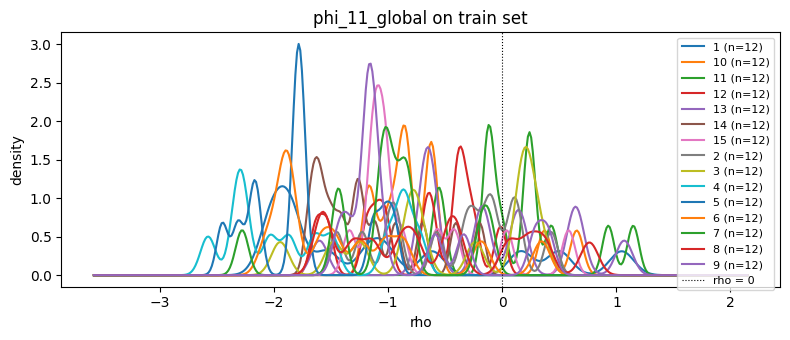

( ( G[36,inf](x_1 <= -0.9) ) ∧ ( G[7,9](x_1 => 1.2) ) )


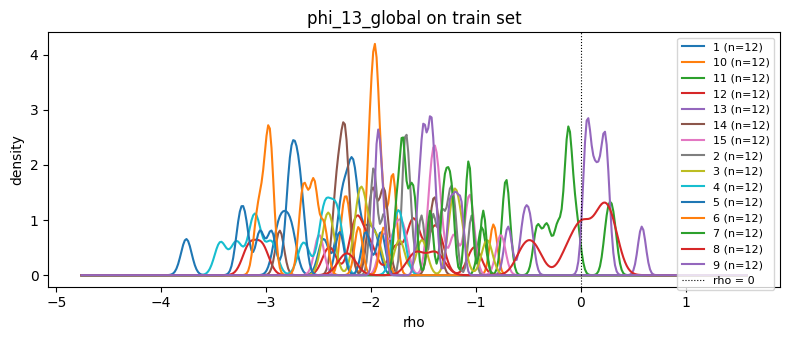

( ( ( G[0,17](x_0 <= 1.2) ) ∧ ( F[39,40](x_1 => -0.7) ) ) ∧ ( G[0,1](x_1 <= 1.6) ) )


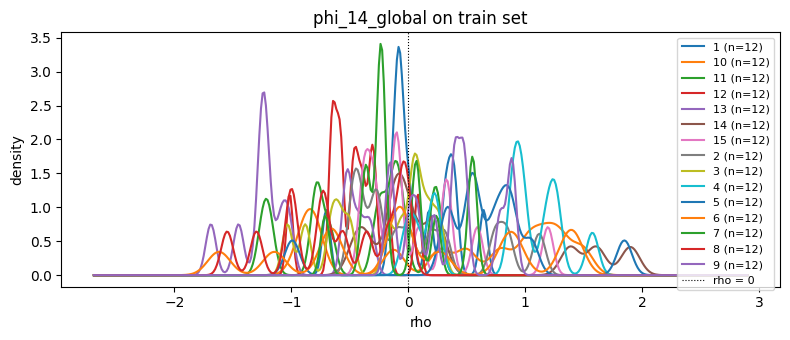


Evaluation on test set:
( ( F[15,22](x_0 <= -0.9) ) ∧ ( F[28,29](x_1 <= -0.5) ) )


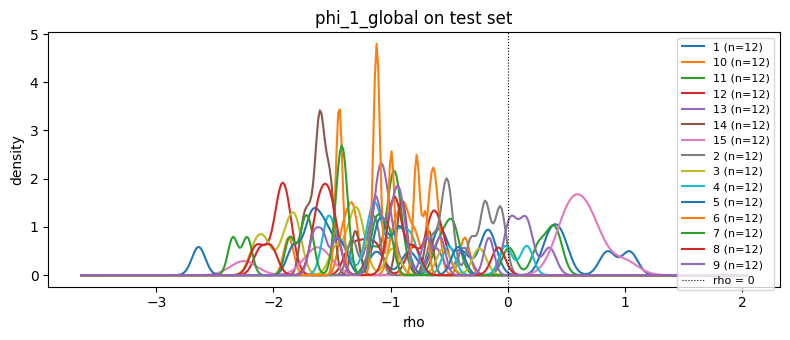

( ( G[9,inf](x_1 => -0.5) ) ∧ ( F[4,17](x_0 <= -0.7284) ) )


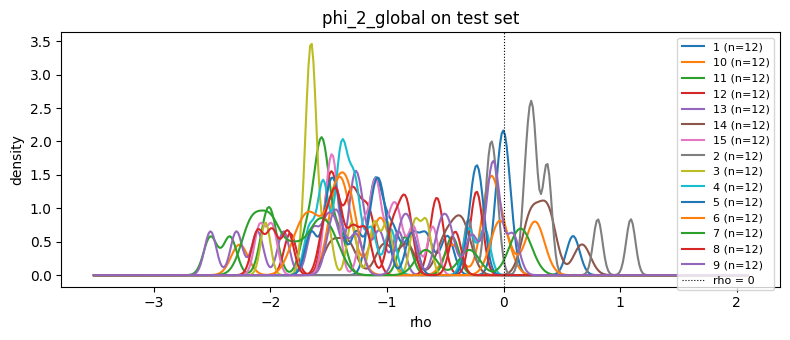

( ( G[9,inf](x_0 <= 0.9) ) ∧ ( F[4,15](x_1 <= -0.3) ) )


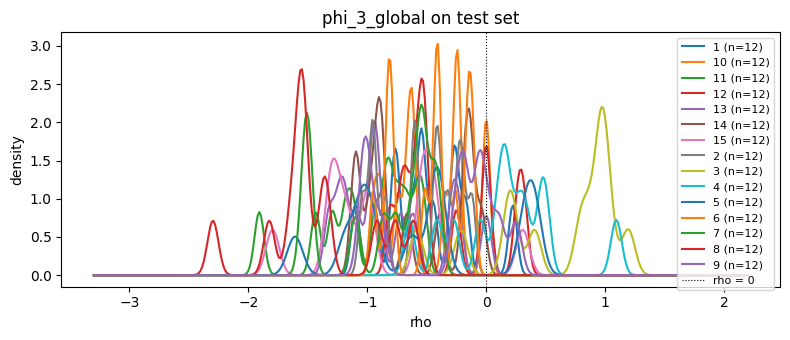

( ( G[10,inf](x_0 => -1.1) ) ∧ ( G[32,inf](x_1 <= -0.2474) ) )


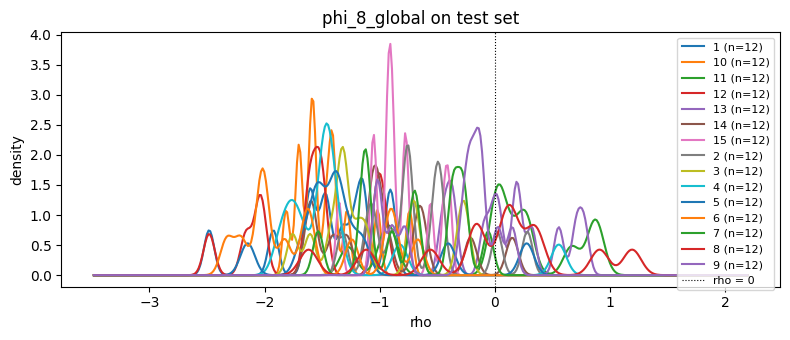

( ( ( G[27,29](x_0 <= 0.1) ) ∧ ( G[39,inf](x_1 => -0.3) ) ) ∧ ( G[2,inf](x_0 <= 1.1) ) )


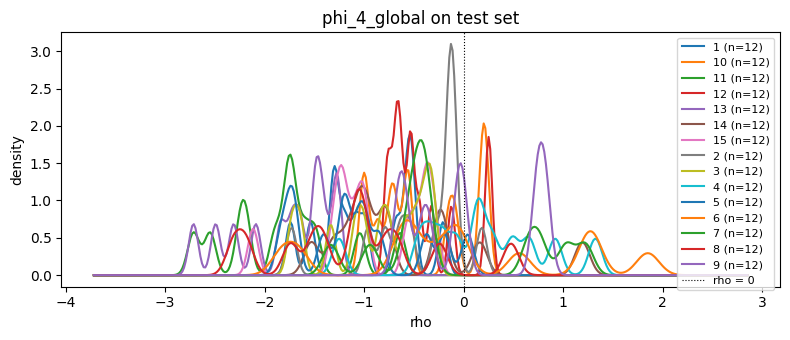

( ( ( G[2,8](x_1 <= 0.4) ) ∧ ( G[26,41](x_1 => -0.7) ) ) ∧ ( G(x_0 <= 1.3) ) )


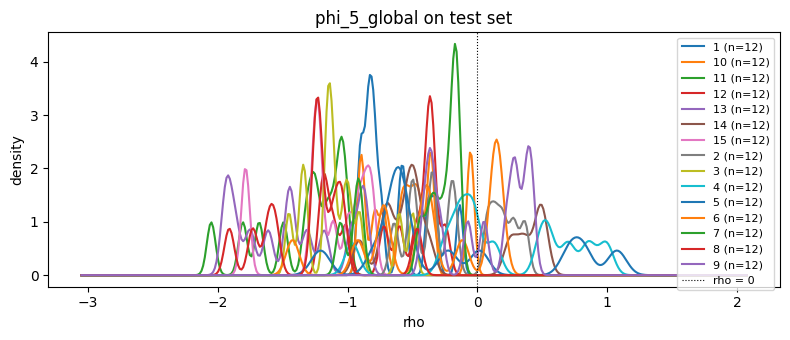

( ( F[27,33](x_1 => 0.9) ) ∧ ( F[16,31](x_0 <= -1.3) ) )


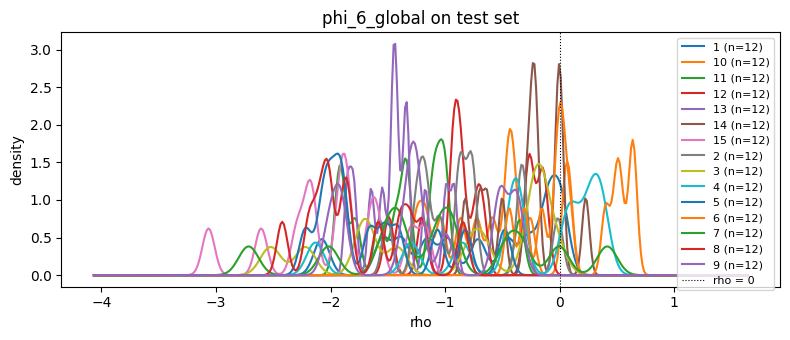

( ( G[14,33](x_1 => -0.1) ) ∧ ( F[7,inf](x_0 <= -1.3) ) )


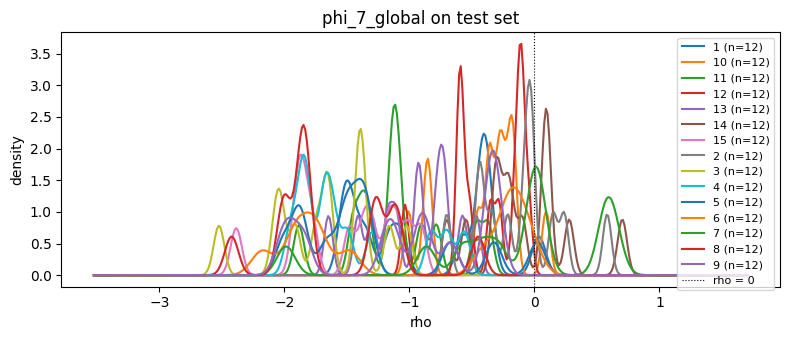

( ¬( ( G[0,17](x_0 <= 1.1446) ) ∧ ( G[28,30](x_1 <= 0.8) ) ) )


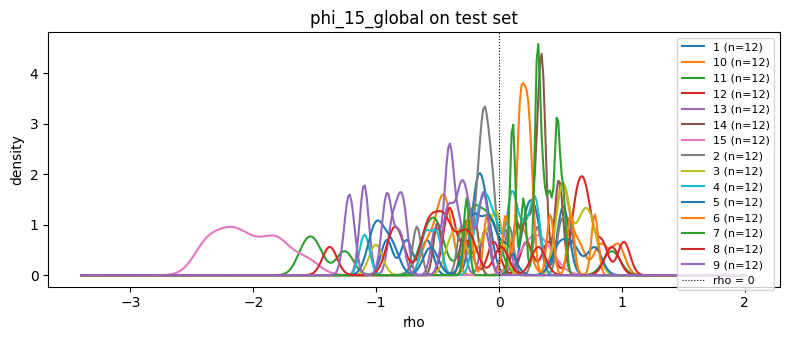

( ( G(x_1 <= 1.1) ) ∧ ( G[5,inf](x_0 <= 1.1) ) )


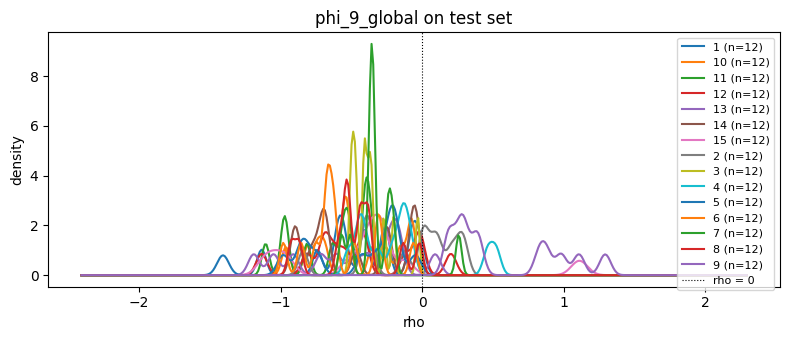

( ( F[0,10](x_0 => 0.6) ) ∧ ( F[22,27](x_1 => 0.5642) ) )


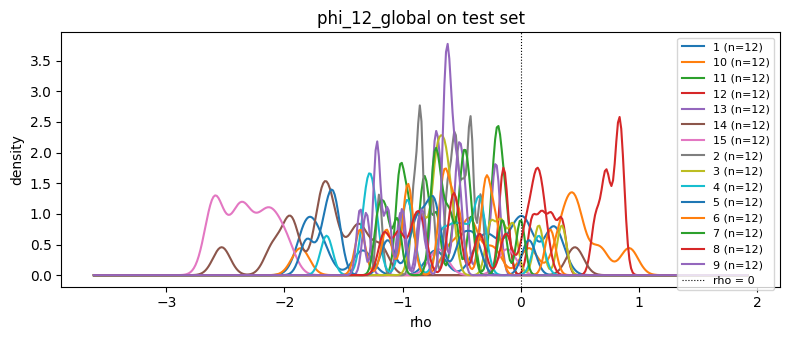

( ( ( F[21,32](x_1 => -0.1) ) ∧ ( G[19,31](x_0 <= 0.5644) ) ) ∧ ( F[1,12](x_1 => -0.1) ) )


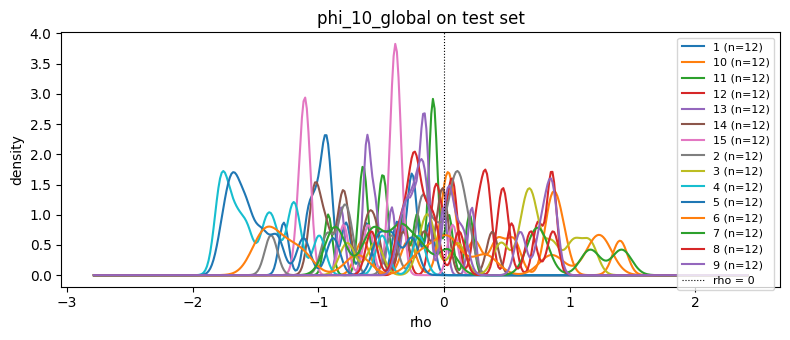

( ( G[1,4](x_1 => 0.4) ) ∧ ( F[13,19](x_0 <= -0.4) ) )


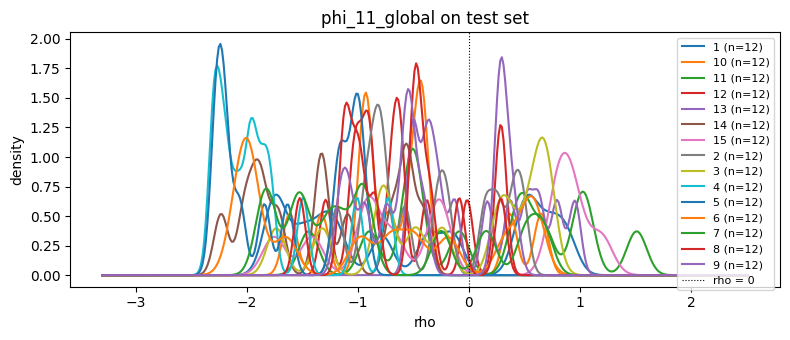

( ( G[36,inf](x_1 <= -0.9) ) ∧ ( G[7,9](x_1 => 1.2) ) )


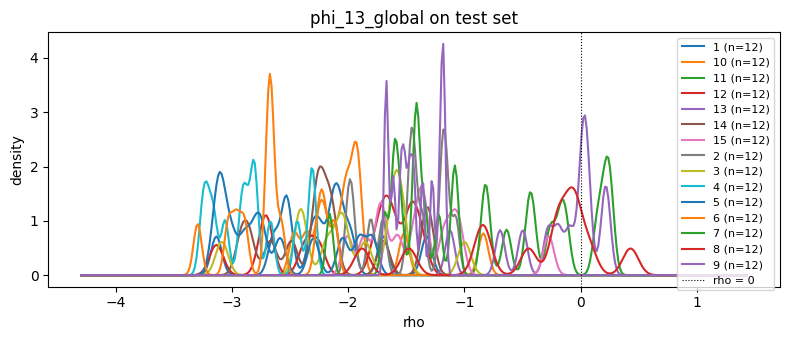

( ( ( G[0,17](x_0 <= 1.2) ) ∧ ( F[39,40](x_1 => -0.7) ) ) ∧ ( G[0,1](x_1 <= 1.6) ) )


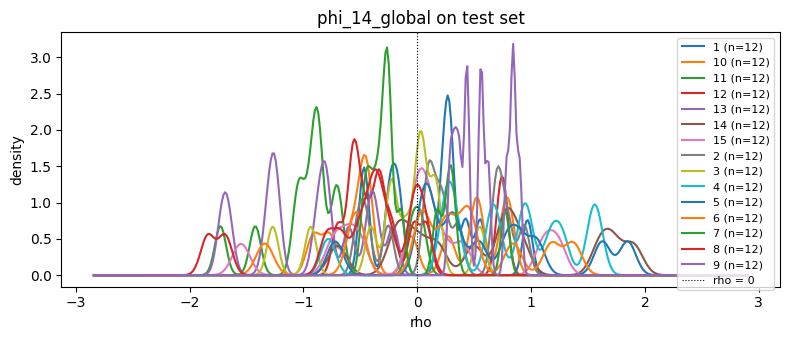

In [67]:
print("Evaluation on train set:")
for cls, phi_global in global_per_class.items():
    print(phi_global)
    plot_robustness_kde(
        phi_global, TS_tr, y_tr, classes, cls,
        title=f"phi_{cls}_global on train set",
    )

print("\nEvaluation on test set:")
for cls, phi_global in global_per_class.items():
    print(phi_global)
    plot_robustness_kde(
        phi_global, TS_te, y_te, classes, cls,
        title=f"phi_{cls}_global on test set",
    )